In [10]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Download required NLTK data
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

nlp = spacy.load("en_core_web_sm")
print("Libraries loaded ✅")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Libraries loaded ✅


In [11]:
with open("../Data/sample_cv.txt", "r") as f:
    cv_text = f.read()

with open("../Data/sample_job.txt", "r") as f:
    job_text = f.read()

print("=== CV TEXT ===")
print(cv_text[:300])
print("\n=== JOB TEXT ===")
print(job_text[:300])

=== CV TEXT ===
John Doe
Email: john@email.com | LinkedIn: linkedin.com/in/johndoe

SUMMARY
Experienced data scientist with 4 years of experience building
machine learning models and data pipelines. Skilled in Python,
SQL, and cloud platforms.

SKILLS
Python, SQL, Pandas, NumPy, Scikit-learn, TensorFlow, Power BI,


=== JOB TEXT ===
Job Title: Senior Data Scientist

We are looking for an experienced Data Scientist to join our team.

Requirements:
- 3+ years of experience in data science or machine learning
- Strong proficiency in Python and SQL
- Experience with machine learning frameworks: Scikit-learn, TensorFlow or PyTorch
-


In [12]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

cv_clean = clean_text(cv_text)
job_clean = clean_text(job_text)

print("CV (cleaned):", cv_clean[:200])
print("\nJob (cleaned):", job_clean[:200])

CV (cleaned): john doe email john email com linkedin linkedin com johndoe summary experienced data scientist years experience building machine learning models data pipelines skilled python sql cloud platforms skill

Job (cleaned): job title senior data scientist looking experienced data scientist join team requirements years experience data science machine learning strong proficiency python sql experience machine learning frame


In [13]:
def extract_keywords(text, top_n=30):
    doc = nlp(text.lower())
    # Extract nouns, proper nouns and adjectives as keywords
    keywords = [token.lemma_ for token in doc
                if token.pos_ in ["NOUN", "PROPN"]
                and not token.is_stop
                and len(token.text) > 2]
    # Count frequency
    freq = pd.Series(keywords).value_counts().head(top_n)
    return freq

cv_keywords = extract_keywords(cv_text)
job_keywords = extract_keywords(job_text)

print("=== Top CV Keywords ===")
print(cv_keywords.head(15))
print("\n=== Top Job Keywords ===")
print(job_keywords.head(15))

=== Top CV Keywords ===
datum         6
python        3
scientist     2
experience    2
model         2
pipeline      2
cloud         2
power         2
aw            2
john          1
doe           1
email         1
summary       1
year          1
building      1
Name: count, dtype: int64

=== Top Job Keywords ===
experience     8
data           4
learning       3
scientist      2
machine        2
tool           2
knowledge      2
job            1
title          1
team           1
requirement    1
year           1
science        1
proficiency    1
python         1
Name: count, dtype: int64


In [14]:
def calculate_match_score(cv, job):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([cv, job])
    score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    return round(score * 100, 2)

score = calculate_match_score(cv_clean, job_clean)
print(f"Match Score: {score}%")

Match Score: 35.82%


In [15]:
def find_missing_keywords(cv_text, job_text):
    # Common tech skills to look for
    tech_skills = [
        "python", "sql", "r", "java", "scala", "spark",
        "tensorflow", "pytorch", "keras", "scikit", "pandas",
        "numpy", "matplotlib", "seaborn", "plotly", "tableau",
        "power bi", "aws", "gcp", "azure", "docker", "kubernetes",
        "airflow", "dbt", "git", "mlops", "nlp", "deep learning",
        "machine learning", "data science", "statistics",
        "neural network", "transformer", "bert", "llm"
    ]

    cv_lower = cv_text.lower()
    job_lower = job_text.lower()

    # Skills in job but missing from CV
    missing = []
    present = []

    for skill in tech_skills:
        if skill in job_lower:
            if skill in cv_lower:
                present.append(skill)
            else:
                missing.append(skill)

    return present, missing

present, missing = find_missing_keywords(cv_text, job_text)
print(f"✅ Skills Present ({len(present)}): {present}")
print(f"\n❌ Skills Missing ({len(missing)}): {missing}")

✅ Skills Present (10): ['python', 'sql', 'r', 'tensorflow', 'scikit', 'power bi', 'aws', 'docker', 'git', 'machine learning']

❌ Skills Missing (12): ['spark', 'pytorch', 'plotly', 'tableau', 'gcp', 'azure', 'airflow', 'dbt', 'mlops', 'nlp', 'deep learning', 'data science']


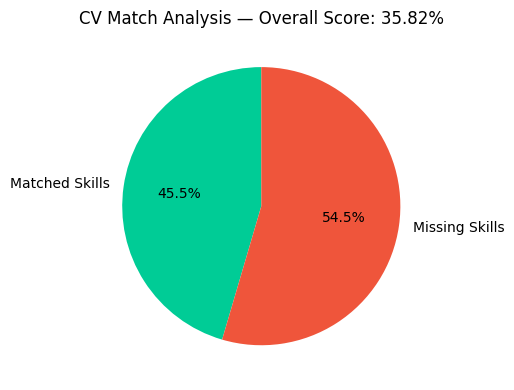

In [16]:
labels = ["Matched Skills", "Missing Skills"]
sizes = [len(present), len(missing)]
colors = ["#00CC96", "#EF553B"]

plt.figure(figsize=(6, 4))
plt.pie(sizes, labels=labels, autopct="%1.1f%%",
        colors=colors, startangle=90)
plt.title(f"CV Match Analysis — Overall Score: {score}%")
plt.tight_layout()
plt.savefig("../match_analysis.png", dpi=150)
plt.show()

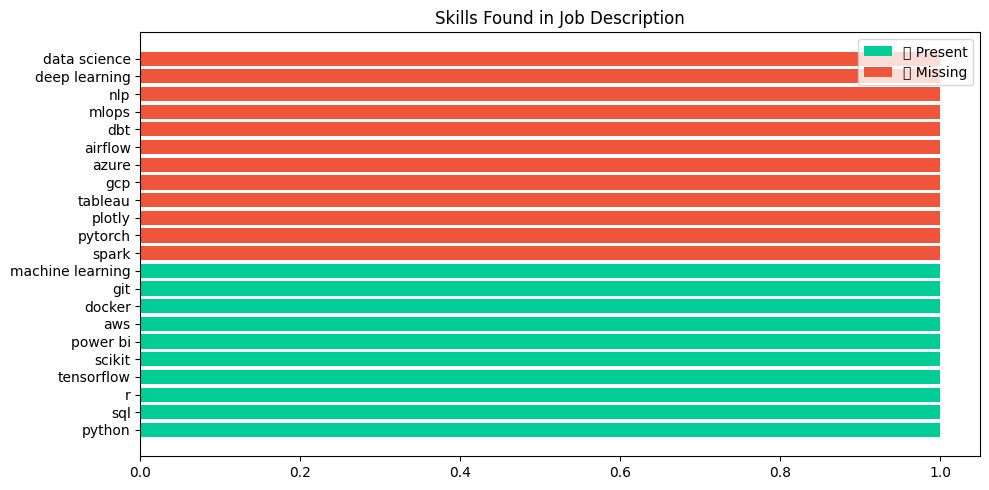

In [17]:
all_skills = [(s, "✅ Present") for s in present] + \
             [(s, "❌ Missing") for s in missing]
skills_df = pd.DataFrame(all_skills, columns=["Skill", "Status"])

plt.figure(figsize=(10, 5))
colors_map = {"✅ Present": "#00CC96", "❌ Missing": "#EF553B"}
for status, group in skills_df.groupby("Status"):
    plt.barh(group["Skill"], [1] * len(group),
             color=colors_map[status], label=status)
plt.title("Skills Found in Job Description")
plt.legend()
plt.tight_layout()
plt.savefig("../skill_gap.png", dpi=150)
plt.show()

## 📋 Key NLP Findings

1. **TF-IDF cosine similarity** is used to score CV-to-job match
2. **spaCy** extracts the most important keywords from both texts
3. **Skill gap analysis** shows exactly which required skills are missing
4. A score above 60% indicates a strong match
5. The tool helps job seekers improve their CVs before applying